# Spot Detection

Spot detection is a fundamental operation in microscopy image analysis for detecting and counting small bright objects, often referred to as "spots". This notebook demonstrates two popular approaches:

1. **Local Maxima Detection** - Simple and fast, useful for well-separated spots
2. **Difference of Gaussian (DoG) Detection** - More sophisticated, relates directly to spot size

Both methods can be combined with intensity thresholding to filter out false positives. We'll explore when and how to use each approach.

In [24]:
import pyclesperanto as cle
import numpy as np
from skimage import io
from matplotlib import pyplot as plt

cle.select_device('GPU')

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

Image shape: (323, 323)
Image dtype: float32
Intensity range: [10001, 24503]


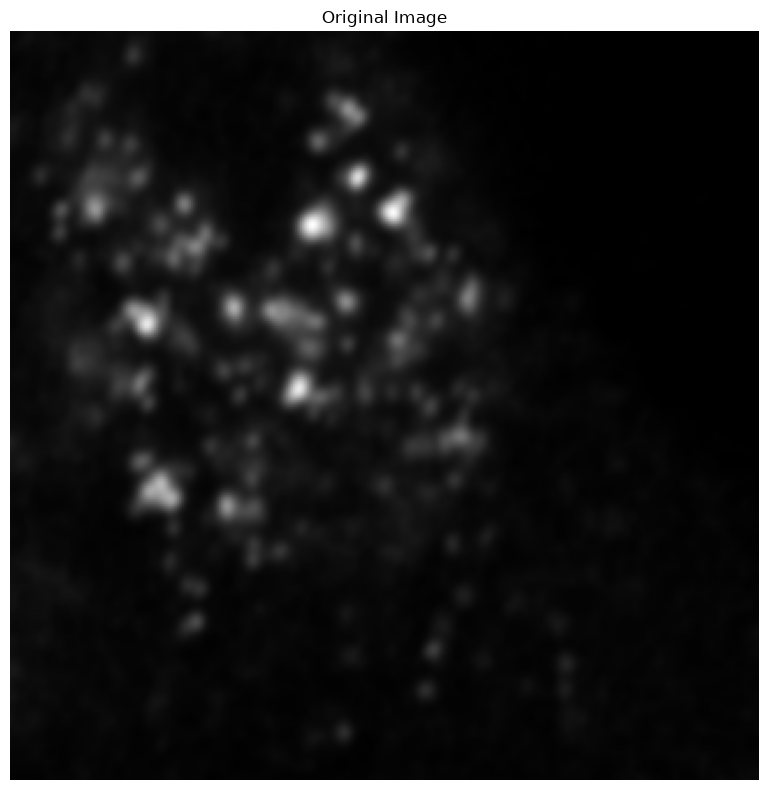

In [25]:
image = cle.push(io.imread('../data/spots.tif').astype(np.float32).squeeze())

print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")
print(f"Intensity range: [{image.min():.0f}, {image.max():.0f}]")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(image.get(), cmap="gray")
ax.set_title('Original Image')
ax.axis('off')
plt.tight_layout()
plt.show()

## Method 1: Local Maxima Detection

The simplest and fastest approach is to find local maxima - pixels that have the highest intensity value within a neighborhood.

**Advantages:**
- Fast and straightforward to compute
- Good for detecting well-separated, isolated spots
- No assumptions about spot size

**Approach:**
1. Apply `cle.detect_maxima()` with a specified radius
2. Optionally apply denoising before detection to remove noise-induced false positives
3. Apply intensity thresholding to filter low-intensity detections

The radius parameter defines the neighborhood size. A larger radius detects larger features.

Number of detected spots (local maxima): 328


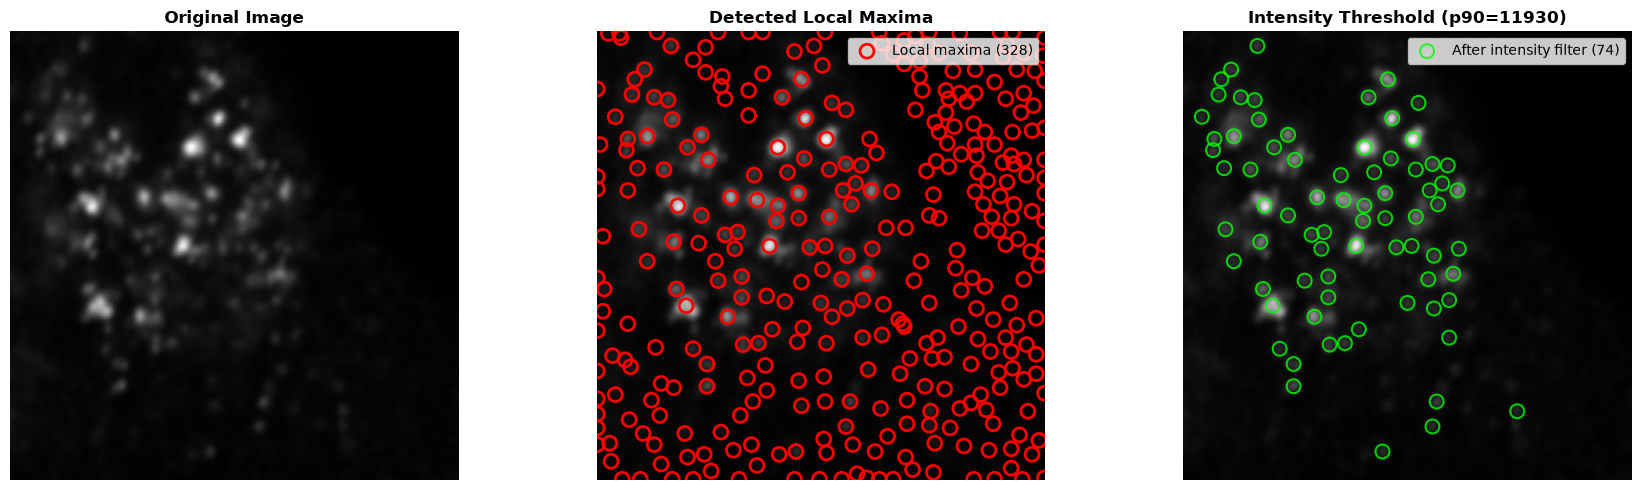

In [26]:
radius_x = 3
radius_y = 3
local_max = cle.detect_maxima(image, radius_x=radius_x, radius_y=radius_y, connectivity='box')

num_spots = int(local_max.sum())
print(f"Number of detected spots (local maxima): {num_spots}")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(image.get(), cmap="gray")
axs[0].set_title('Original Image', fontsize=12, fontweight='bold')
axs[0].axis('off')

axs[1].imshow(image.get(), cmap="gray")
y, x = np.where(local_max.get() > 0)
axs[1].scatter(x, y, s=100, c='none', edgecolors='red', linewidths=2, label=f'Local maxima ({num_spots})')
axs[1].set_title('Detected Local Maxima', fontsize=12, fontweight='bold')
axs[1].legend(loc='upper right', fontsize=10)
axs[1].axis('off')

intensity_threshold = np.percentile(image.get(), 90)
filtered_maxima = local_max * (image > intensity_threshold)
num_filtered_maxima = int(filtered_maxima.sum())
axs[2].imshow(image.get(), cmap="gray")
y_filt, x_filt = np.where(filtered_maxima.get() > 0)
axs[2].scatter(x_filt, y_filt, s=100, c='none', edgecolors='lime', linewidths=1.5, 
               label=f'After intensity filter ({num_filtered_maxima})', alpha=0.8)
axs[2].set_title(f'Intensity Threshold (p90={intensity_threshold:.0f})', fontsize=12, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=10)
axs[2].axis('off')

plt.tight_layout()
plt.show()

## Method 2: Difference of Gaussian (DoG) Detection

The Difference of Gaussian is a more sophisticated approach that provides better scale-space analysis for spot detection.

**Theory:**
- Computes the difference between two Gaussian filters with different standard deviations (sigma)
- The response is maximal when the spot size matches the difference in sigma values
- The formula `σ ≈ d / (2√2)` relates sigma to the diameter `d` of objects of interest

**Advantages:**
- Directly relates filter response to object size
- Better at suppressing background noise
- Provides quality measure: high DoG values = objects that match the expected size well
- Can be tuned to detect spots of specific sizes

**Approach:**
1. Apply `cle.difference_of_gaussian()` with appropriate sigma values
2. Detect local maxima in the DoG response
3. Use the DoG intensity values as a quality measure for filtering

Sigma1: (1.0, 1.0), Sigma2: (2.0, 2.0)
Number of detected spots (DoG maxima): 1233
DoG intensity range: [-544.6, 1969.3]


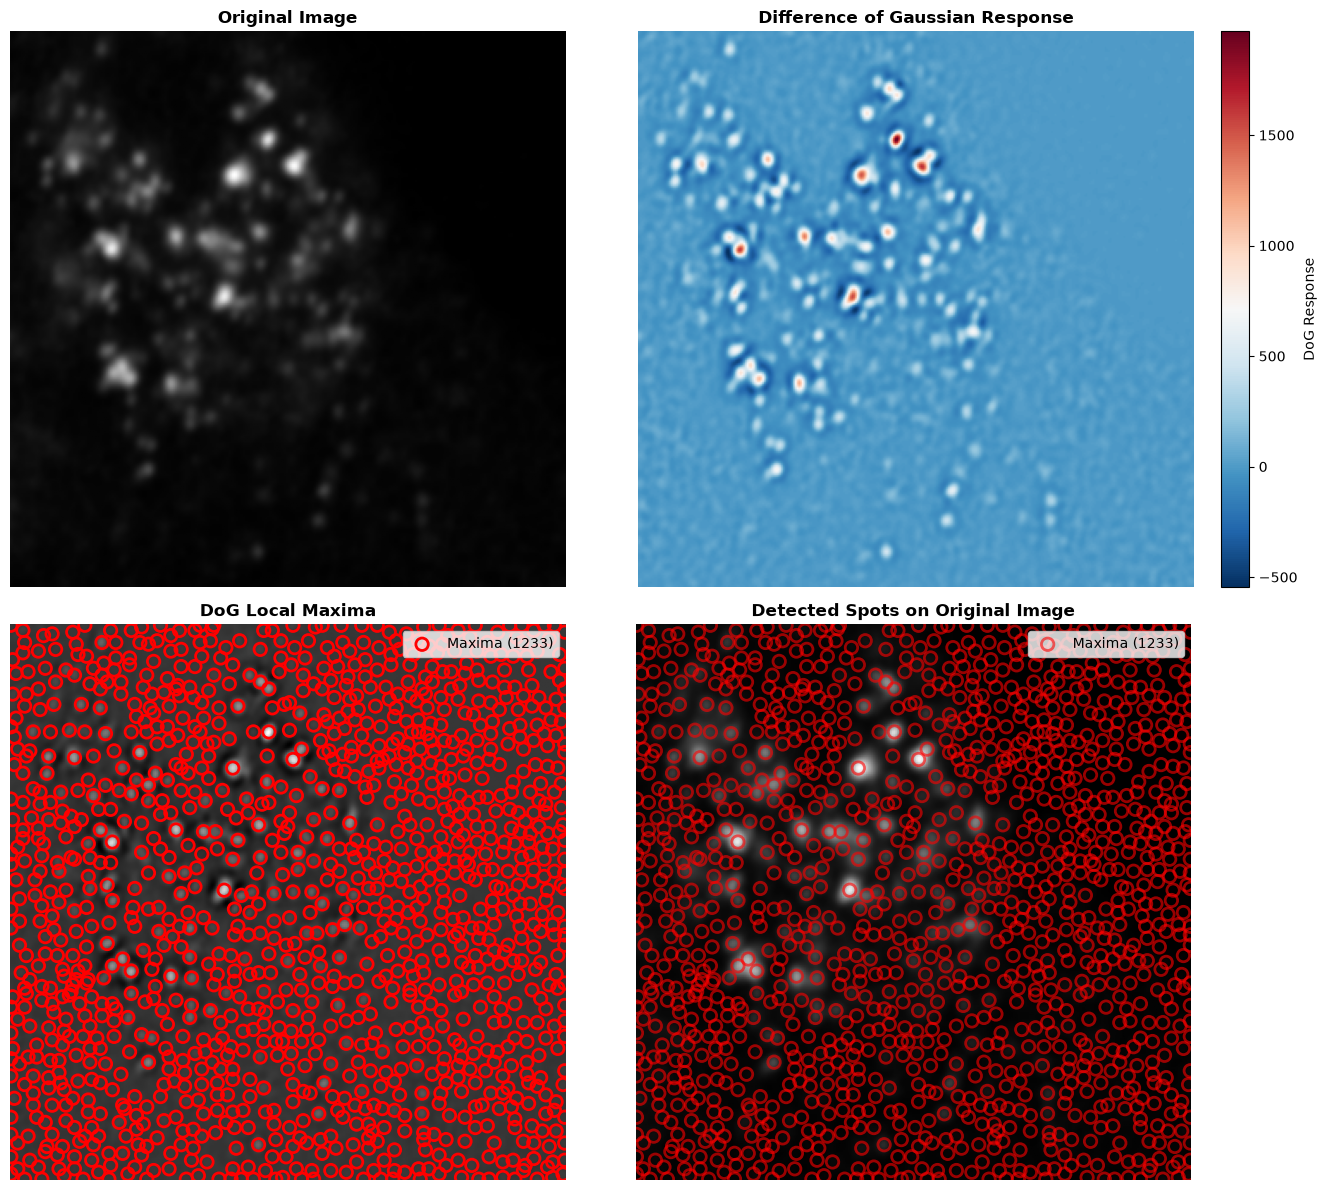

In [27]:
sigma1_x = 1.0
sigma1_y = 1.0
sigma2_x = 2.0
sigma2_y = 2.0

dog = cle.difference_of_gaussian(image, sigma1_x=sigma1_x, sigma1_y=sigma1_y, 
                                 sigma2_x=sigma2_x, sigma2_y=sigma2_y)

dog_maxima = cle.detect_maxima(dog, radius_x=0, radius_y=0, connectivity='box')
num_dog_spots = int(dog_maxima.sum())

print(f"Sigma1: ({sigma1_x}, {sigma1_y}), Sigma2: ({sigma2_x}, {sigma2_y})")
print(f"Number of detected spots (DoG maxima): {num_dog_spots}")
print(f"DoG intensity range: [{dog.min():.1f}, {dog.max():.1f}]")

fig, axs = plt.subplots(2, 2, figsize=(14, 12))

axs[0, 0].imshow(image.get(), cmap="gray")
axs[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axs[0, 0].axis('off')

axs[0, 1].imshow(dog.get(), cmap="RdBu_r")
cbar = plt.colorbar(axs[0, 1].images[0], ax=axs[0, 1], fraction=0.046, pad=0.04)
cbar.set_label('DoG Response', fontsize=10)
axs[0, 1].set_title('Difference of Gaussian Response', fontsize=12, fontweight='bold')
axs[0, 1].axis('off')

axs[1, 0].imshow(dog.get(), cmap="gray")
y_dog, x_dog = np.where(dog_maxima.get() > 0)
axs[1, 0].scatter(x_dog, y_dog, s=80, c='none', edgecolors='red', linewidths=2, 
                  label=f'Maxima ({num_dog_spots})')
axs[1, 0].set_title('DoG Local Maxima', fontsize=12, fontweight='bold')
axs[1, 0].legend(loc='upper right', fontsize=10)
axs[1, 0].axis('off')

axs[1, 1].imshow(image.get(), cmap="gray")
axs[1, 1].scatter(x_dog, y_dog, s=80, c='none', edgecolors='red', linewidths=2, 
                  label=f'Maxima ({num_dog_spots})', alpha=0.6)
axs[1, 1].set_title('Detected Spots on Original Image', fontsize=12, fontweight='bold')
axs[1, 1].legend(loc='upper right', fontsize=10)
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Understanding Spot Quality via DoG Response

One powerful aspect of DoG detection is that the intensity values in the DoG response can be interpreted as a "quality" measure:
- **Higher values**: Objects that match the expected size (between sigma1 and sigma2)
- **Lower values**: Objects that are too small, too large, or background noise
- This allows post-filtering based on the quality of the match, not just binary presence/absence

Quality statistics (DoG intensity at spots):
  Mean: 72.11
  Std Dev: 184.53
  Min: -110.62
  Max: 1969.34
  Median: 19.61


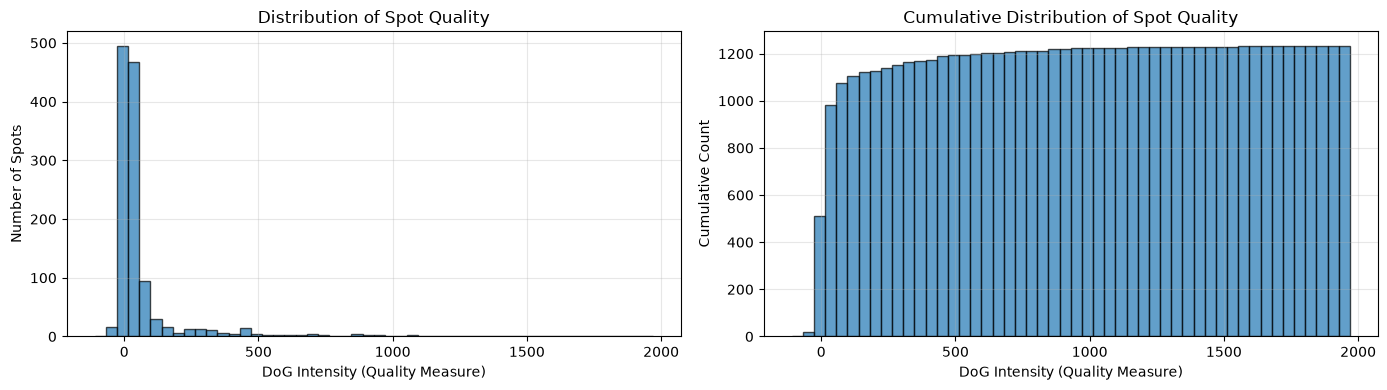

In [28]:
labeled_spots = cle.label_spots(dog_maxima)
spot_props = cle.labels_statistics(labeled_spots, dog, include_background=False)
dog_intensities = np.array(spot_props["max_intensity"])

print(f"Quality statistics (DoG intensity at spots):")
print(f"  Mean: {dog_intensities.mean():.2f}")
print(f"  Std Dev: {dog_intensities.std():.2f}")
print(f"  Min: {dog_intensities.min():.2f}")
print(f"  Max: {dog_intensities.max():.2f}")
print(f"  Median: {np.median(dog_intensities):.2f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].hist(dog_intensities, bins=50, edgecolor='black', alpha=0.7)
axs[0].set_xlabel('DoG Intensity (Quality Measure)')
axs[0].set_ylabel('Number of Spots')
axs[0].set_title('Distribution of Spot Quality')
axs[0].grid(alpha=0.3)

axs[1].hist(dog_intensities, bins=50, cumulative=True, alpha=0.7, edgecolor='black')
axs[1].set_xlabel('DoG Intensity (Quality Measure)')
axs[1].set_ylabel('Cumulative Count')
axs[1].set_title('Cumulative Distribution of Spot Quality')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Applying quality threshold: 154.19
Spots above quality threshold: 124 / 1233
Spots filtered out: 1109


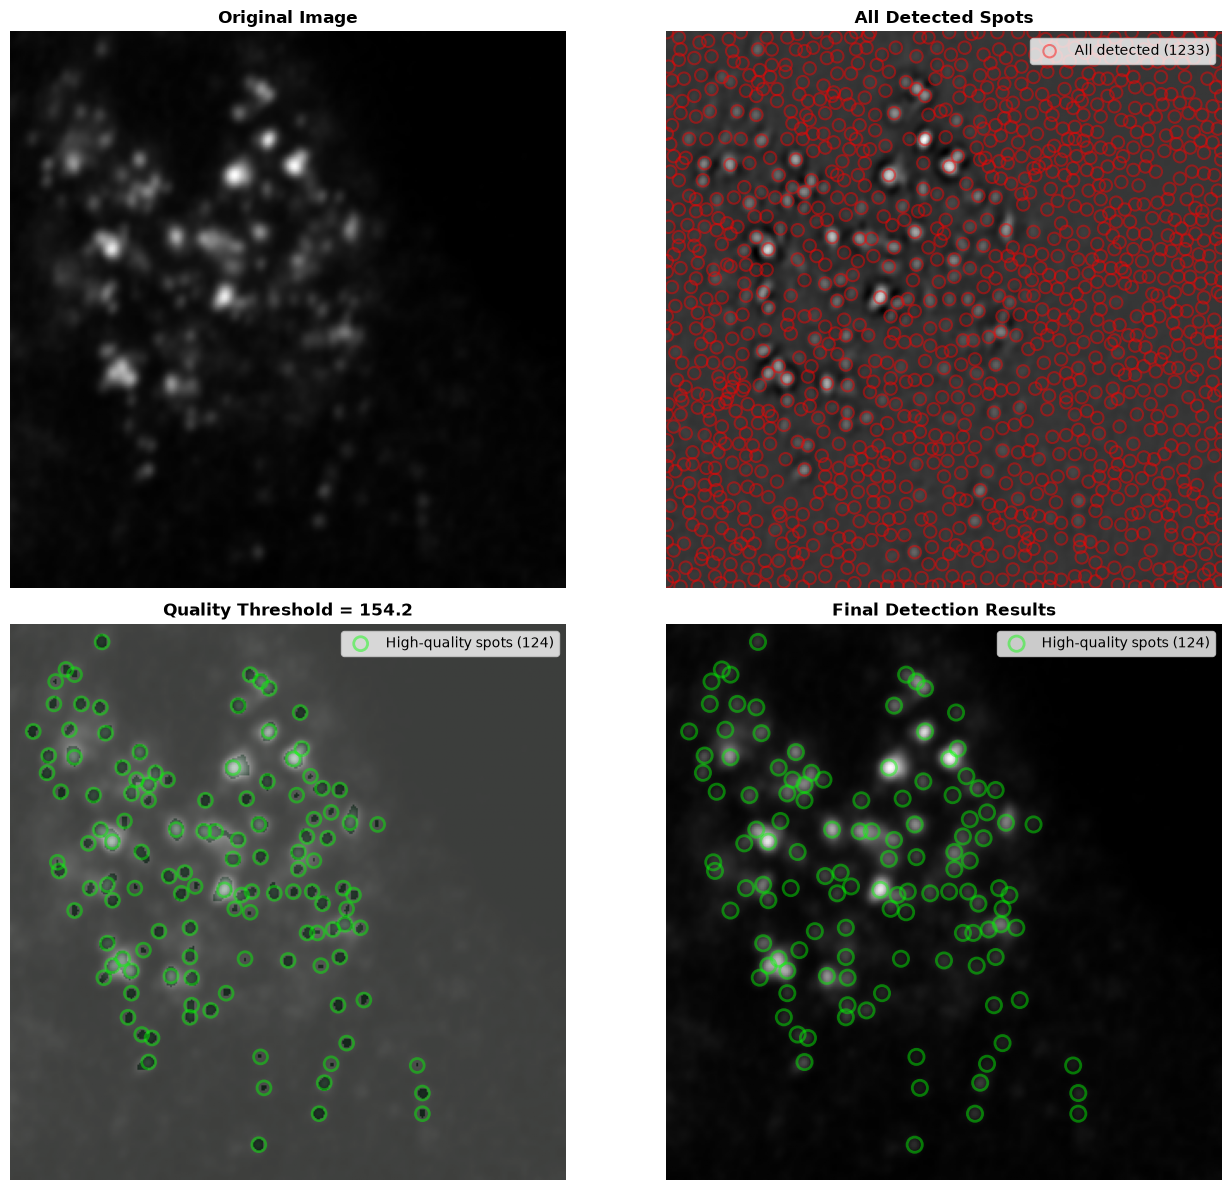

In [29]:
quality_threshold = np.percentile(dog_intensities, 90)
print(f"\nApplying quality threshold: {quality_threshold:.2f}")

high_quality_spots = dog_maxima * (dog > quality_threshold)
num_high_quality = int(high_quality_spots.sum())

print(f"Spots above quality threshold: {num_high_quality} / {num_dog_spots}")
print(f"Spots filtered out: {num_dog_spots - num_high_quality}")

fig, axs = plt.subplots(2, 2, figsize=(14, 12))

axs[0, 0].imshow(image.get(), cmap="gray")
axs[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axs[0, 0].axis('off')

axs[0, 1].imshow(dog.get(), cmap="gray")
axs[0, 1].scatter(x_dog, y_dog, s=80, c='none', edgecolors='red', linewidths=1.5, 
                  label=f'All detected ({num_dog_spots})', alpha=0.45)
axs[0, 1].set_title('All Detected Spots', fontsize=12, fontweight='bold')
axs[0, 1].legend(loc='upper right', fontsize=10)
axs[0, 1].axis('off')

quality_mask = dog > quality_threshold
axs[1, 0].imshow(image.get(), cmap="gray")
axs[1, 0].imshow(quality_mask.get(), cmap="Greens", alpha=0.25)
y_high, x_high = np.where(high_quality_spots.get() > 0)
axs[1, 0].scatter(x_high, y_high, s=100, c='none', edgecolors='lime', linewidths=2, 
                  label=f'High-quality spots ({num_high_quality})', alpha=0.45)
axs[1, 0].set_title(f'Quality Threshold = {quality_threshold:.1f}', fontsize=12, fontweight='bold')
axs[1, 0].legend(loc='upper right', fontsize=10)
axs[1, 0].axis('off')

axs[1, 1].imshow(image.get(), cmap="gray")
axs[1, 1].scatter(x_high, y_high, s=120, c='none', edgecolors='lime', linewidths=2, 
                  label=f'High-quality spots ({num_high_quality})', alpha=0.45)
axs[1, 1].set_title('Final Detection Results', fontsize=12, fontweight='bold')
axs[1, 1].legend(loc='upper right', fontsize=10)
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Summary and Recommendations

### Local Maxima Detection
- **Use when:** Spots are well-separated and clearly isolated
- **Pros:** Fast, simple, no parameters to tune
- **Cons:** Sensitive to noise, doesn't encode size information

### Difference of Gaussian (DoG)
- **Use when:** You need size-specific detection or have noisy images
- **Pros:** Size-aware, provides quality metric, better noise suppression
- **Cons:** Requires tuning sigma parameters to match expected spot size

### Tips for Best Results
1. **Choose sigma based on your spot size**: Use `σ ≈ diameter / (2√2)`
2. **Visualize the DoG response**: Check if your spots appear as peaks in the DoG
3. **Use quality filtering**: Leverage DoG intensity values to filter false positives
4. **Adjust thresholds**: The 50th percentile is just a starting point - experiment with your data
5. **Combine methods**: You can try both and compare results on your specific data

Both methods are GPU-accelerated in pyclesperanto, making them efficient even for large image volumes.

/var/folders/ny/v5c8rtv951xgt4_v3tsvcptw0000gp/T/ipykernel_42538/100611355.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


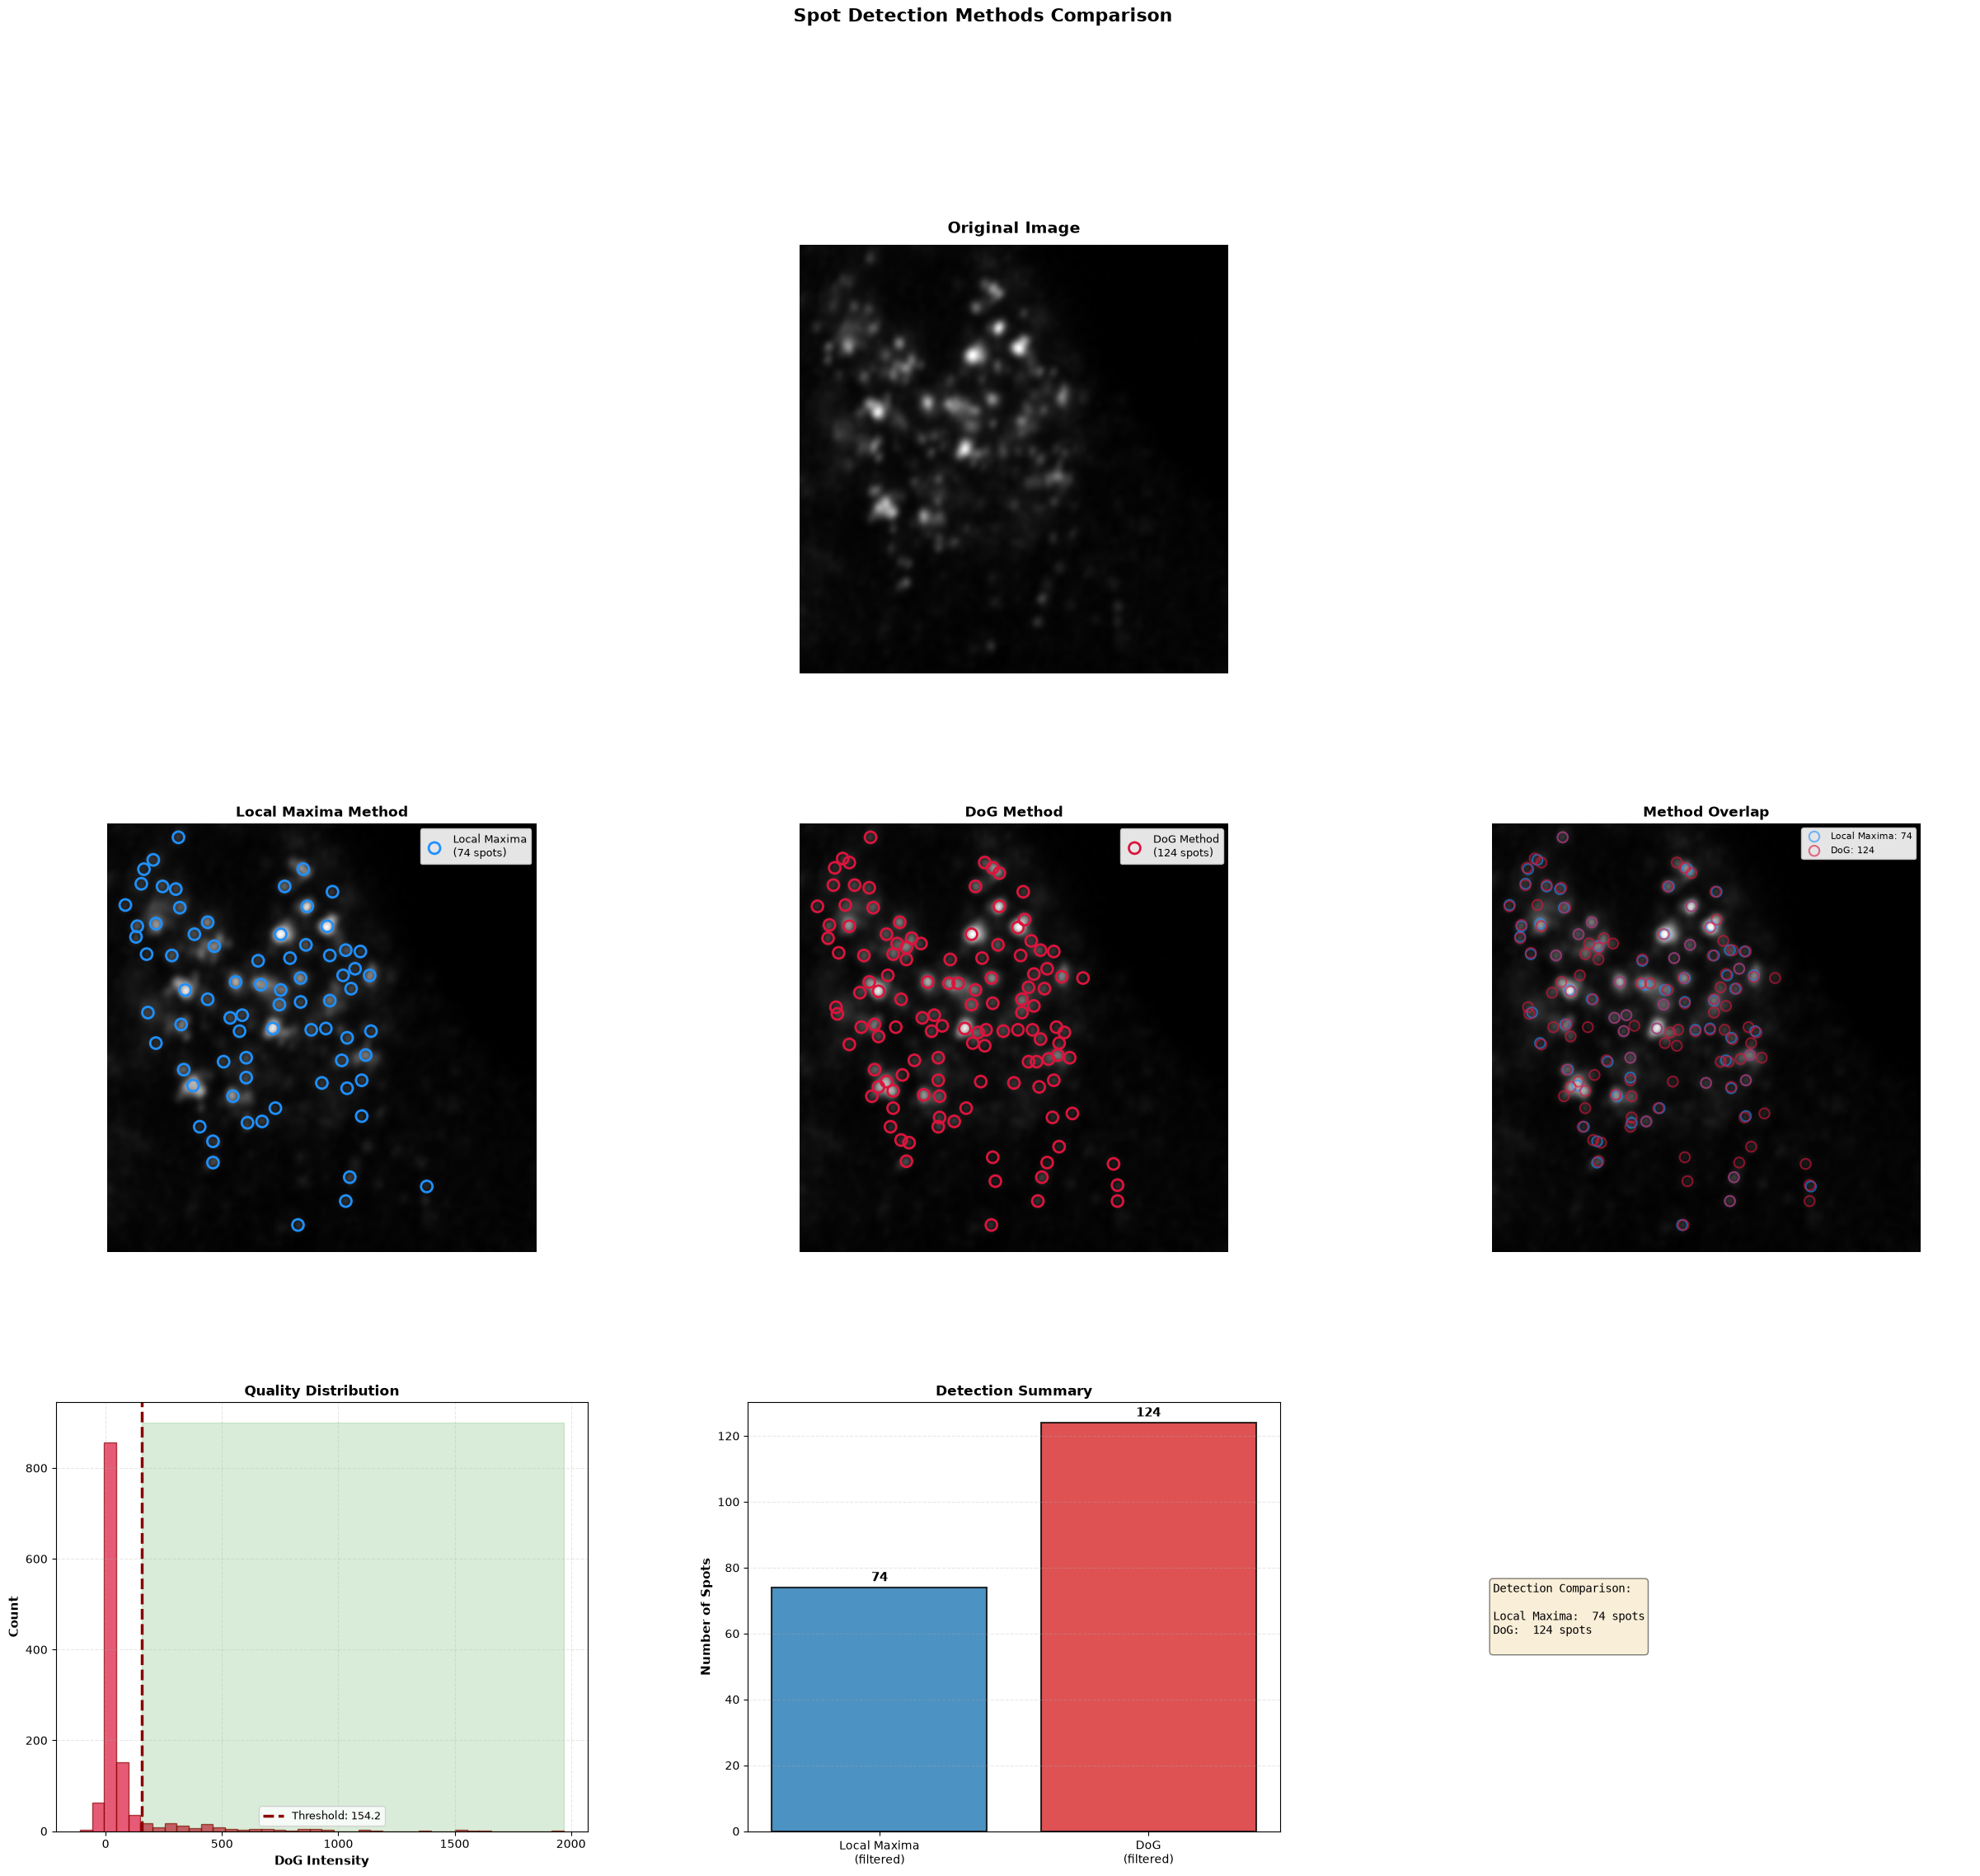


Comparison Summary:
  Local Maxima (filtered): 74 spots
  DoG (filtered): 124 spots


In [30]:
fig = plt.figure(figsize=(30, 25))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.imshow(image.get(), cmap="gray")
ax1.set_title('Original Image', fontsize=14, fontweight='bold', pad=10)
ax1.axis('off')

ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(image.get(), cmap="gray")
y_lm, x_lm = np.where(filtered_maxima.get() > 0)
ax2.scatter(x_lm, y_lm, s=100, c='none', edgecolors='dodgerblue', linewidths=2, label=f'Local Maxima\n({num_filtered_maxima} spots)')
ax2.set_title('Local Maxima Method', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.axis('off')

ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(image.get(), cmap="gray")
ax3.scatter(x_high, y_high, s=100, c='none', edgecolors='crimson', linewidths=2, label=f'DoG Method\n({num_high_quality} spots)')
ax3.set_title('DoG Method', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax3.axis('off')

ax4 = fig.add_subplot(gs[1, 2])
ax4.imshow(image.get(), cmap="gray")
overlap = filtered_maxima * high_quality_spots
num_overlap = int(overlap.sum())
ax4.scatter(x_lm, y_lm, s=80, c='none', edgecolors='dodgerblue', linewidths=1.5, alpha=0.6, label=f'Local Maxima: {num_filtered_maxima}')
ax4.scatter(x_high, y_high, s=80, c='none', edgecolors='crimson', linewidths=1.5, alpha=0.6, label=f'DoG: {num_high_quality}')
y_overlap, x_overlap = np.where(overlap.get() > 0)
ax4.set_title('Method Overlap', fontsize=12, fontweight='bold')
ax4.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax4.axis('off')

ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(dog_intensities, bins=40, alpha=0.7, color='crimson', edgecolor='darkred')
ax5.axvline(quality_threshold, color='darkred', linestyle='--', linewidth=2.5, label=f'Threshold: {quality_threshold:.1f}')
ax5.fill_betweenx([0, ax5.get_ylim()[1]], quality_threshold, dog_intensities.max(), alpha=0.15, color='green')
ax5.set_xlabel('DoG Intensity', fontsize=11, fontweight='bold')
ax5.set_ylabel('Count', fontsize=11, fontweight='bold')
ax5.set_title('Quality Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, linestyle='--')

ax6 = fig.add_subplot(gs[2, 1])
method_counts = ['Local Maxima\n(filtered)', 'DoG\n(filtered)']
counts = [num_filtered_maxima, num_high_quality]
colors_bar = ['#1f77b4', '#d62728']
bars = ax6.bar(method_counts, counts, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax6.set_ylabel('Number of Spots', fontsize=11, fontweight='bold')
ax6.set_title('Detection Summary', fontsize=12, fontweight='bold')
ax6.grid(alpha=0.3, axis='y', linestyle='--')
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count), 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax7 = fig.add_subplot(gs[2, 2])
stats_text = f"""Detection Comparison:

Local Maxima:  {num_filtered_maxima} spots
DoG:  {num_high_quality} spots
"""
ax7.text(0.1, 0.5, stats_text, transform=ax7.transAxes, fontsize=10, 
         verticalalignment='center', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax7.axis('off')

plt.suptitle('Spot Detection Methods Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\nComparison Summary:")
print(f"  Local Maxima (filtered): {num_filtered_maxima} spots")
print(f"  DoG (filtered): {num_high_quality} spots")